# 🔬 Identificación de hurto de energía a partir del histórico de consumo

**Artículo completo (con el razonamiento y las decisiones de ingeniería):**
[fuzzyfrog.ai/es/ai-lab/proyectos/energia/identificacion-hurto-energia-clustering-random-forest](https://fuzzyfrog.ai/es/ai-lab/proyectos/energia/identificacion-hurto-energia-clustering-random-forest/)

- Objetivo: separar servicios con hurto confirmado de servicios normales, usando solo el histórico mensual de consumo (kWh) de cada uno.
- El dataset es **sintético**: replica la estructura, el desbalance de clases y el comportamiento típico de un histórico real de consumo, pero ningún dato aquí proviene de un cliente real.
- Dos enfoques en paralelo: clustering no supervisado (K-Means) para caracterizar el comportamiento, y un clasificador supervisado (Random Forest + SMOTE) para separar hurto de no-hurto.
- La variable objetivo (`Hurtos`) está fuertemente desbalanceada, como ocurre en la vida real: los hurtos confirmados son una fracción pequeña del total de servicios.


## 🗺️ Diagrama del pipeline

```
Histórico de consumo (servicio × mes)
        │
        ▼
Ingeniería de características por servicio
  (media, mínimo, máximo, desviación estándar, tendencia)
        │
        ├──► K-Means (2 clusters)  ──► caracterización del comportamiento
        │
        └──► Random Forest + SMOTE ──► clasificación hurto / no-hurto
                    │
                    ▼
        Lista de servicios objetivo para inspección
```

No hay arquitectura de red ni app involucrada aquí: es un pipeline de datos puro, así que el diagrama se queda a nivel de flujo de información, no de componentes de infraestructura.


## 📥 Carga de datos

- Generamos el histórico sintético directamente en este notebook, con semilla fija para que sea reproducible.
- 300 servicios en total, con 12 lecturas mensuales de consumo (`ConsumoEAT`) cada uno.
- ~13% de los servicios están etiquetados como `Hurtos = 1`, una proporción cercana a la que reportan estudios de pérdidas no técnicas en redes de baja tensión en la región.
- El consumo de los servicios con hurto se genera con una caída abrupta y sostenida en algún punto del histórico, simulando manipulación del medidor; el resto sigue un patrón estacional con ruido normal.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(7)

N_SERVICIOS = 300
N_MESES = 12
PROP_HURTO = 0.13
PROP_BAJA_NATURAL = 0.10  # servicios normales que también bajan consumo (mudanza, cierre parcial, ahorro)

periodos = pd.date_range("2023-06-01", periods=N_MESES, freq="MS")
tarifas = np.random.choice(
    ["Residencial", "Comercial", "Industrial"],
    size=N_SERVICIOS, p=[0.6, 0.3, 0.1]
)

base_por_tarifa = {"Residencial": 180, "Comercial": 520, "Industrial": 2400}
ruido_por_tarifa = {"Residencial": 30, "Comercial": 95, "Industrial": 420}

registros = []
es_hurto = np.random.rand(N_SERVICIOS) < PROP_HURTO
baja_natural = (~es_hurto) & (np.random.rand(N_SERVICIOS) < PROP_BAJA_NATURAL)

for i in range(N_SERVICIOS):
    servicio_id = 100000 + i
    tarifa = tarifas[i]
    base = base_por_tarifa[tarifa]
    ruido = ruido_por_tarifa[tarifa]
    estacionalidad = 1 + 0.10 * np.sin(np.linspace(0, 2 * np.pi, N_MESES) + np.random.uniform(0, np.pi))

    consumo = base * estacionalidad + np.random.normal(0, ruido, N_MESES)

    if es_hurto[i]:
        # punto de quiebre: a partir de aquí el consumo cae, simulando manipulación
        # del medidor o conexión directa. La caída es parcial y con ruido, no un
        # escalón perfecto, para que no sea trivialmente separable.
        quiebre = np.random.randint(3, N_MESES - 2)
        factor_caida = np.random.uniform(0.35, 0.70)
        consumo[quiebre:] = consumo[quiebre:] * factor_caida + np.random.normal(0, ruido * 0.8, N_MESES - quiebre)
    elif baja_natural[i]:
        # servicio legítimo que también reduce consumo por razones normales
        # (cierre parcial, ahorro, cambio de hábito) — el ruido difícil real
        quiebre = np.random.randint(4, N_MESES - 1)
        factor_caida = np.random.uniform(0.55, 0.80)
        consumo[quiebre:] = consumo[quiebre:] * factor_caida + np.random.normal(0, ruido * 0.8, N_MESES - quiebre)

    consumo = np.clip(consumo, 5, None)

    for periodo, valor in zip(periodos, consumo):
        registros.append({
            "IdNroServicio": servicio_id,
            "Tarifa": tarifa,
            "Periodo": periodo,
            "ConsumoEAT": round(float(valor), 2),
            "Hurtos": int(es_hurto[i])
        })

df = pd.DataFrame(registros)
df.to_csv("outputs/dataset_sintetico_consumo.csv", index=False)
df.head(10)


,IdNroServicio,Tarifa,Periodo,ConsumoEAT,Hurtos
0,100000,Residencial,2023-06-01,198.16,0
1,100000,Residencial,2023-07-01,171.82,0
2,100000,Residencial,2023-08-01,190.26,0
3,100000,Residencial,2023-09-01,183.12,0
4,100000,Residencial,2023-10-01,200.30,0
5,100000,Residencial,2023-11-01,156.64,0
6,100000,Residencial,2023-12-01,130.74,0
7,100000,Residencial,2024-01-01,186.68,0
8,100000,Residencial,2024-02-01,211.07,0
9,100000,Residencial,2024-03-01,148.58,0


## 📋 Explicación de datos

- **IdNroServicio**: identificador del servicio (sintético, no corresponde a ningún cliente real).
- **Tarifa**: categoría del servicio (Residencial, Comercial, Industrial), afecta la magnitud del consumo esperado.
- **Periodo**: mes de la lectura.
- **ConsumoEAT**: consumo en kWh reportado para ese servicio en ese mes.
- **Hurtos**: etiqueta binaria (1 = hurto confirmado, 0 = servicio normal). En un caso real esta etiqueta viene de inspecciones de campo, no del propio consumo; aquí la generamos junto con los datos porque el dataset es sintético.

> **Nota:** el dataset usado en este notebook es completamente sintético. Fue creado para fines demostrativos y no contiene información de ningún cliente o proyecto real.


In [2]:
print(f"Servicios únicos: {df['IdNroServicio'].nunique()}")
print(f"Registros totales: {len(df)}")
print()
print("Distribución de la etiqueta Hurtos (por servicio):")
print(df.groupby('IdNroServicio')['Hurtos'].first().value_counts())
print()
print("Distribución por tarifa:")
print(df.groupby('IdNroServicio')['Tarifa'].first().value_counts())


Servicios únicos: 300
Registros totales: 3600

Distribución de la etiqueta Hurtos (por servicio):
Hurtos
0    260
1     40
Name: count, dtype: int64

Distribución por tarifa:
Tarifa
Residencial    185
Comercial       87
Industrial      28
Name: count, dtype: int64


## 🔍 Análisis exploratorio (EDA)

- Antes de construir cualquier característica, visualizamos el histórico de consumo de un servicio normal contra uno con hurto.
- El objetivo es confirmar visualmente que el patrón que estamos simulando (caída abrupta y sostenida) es consistente con lo que reporta la literatura sobre manipulación de medidores, y no un artefacto arbitrario del generador sintético.


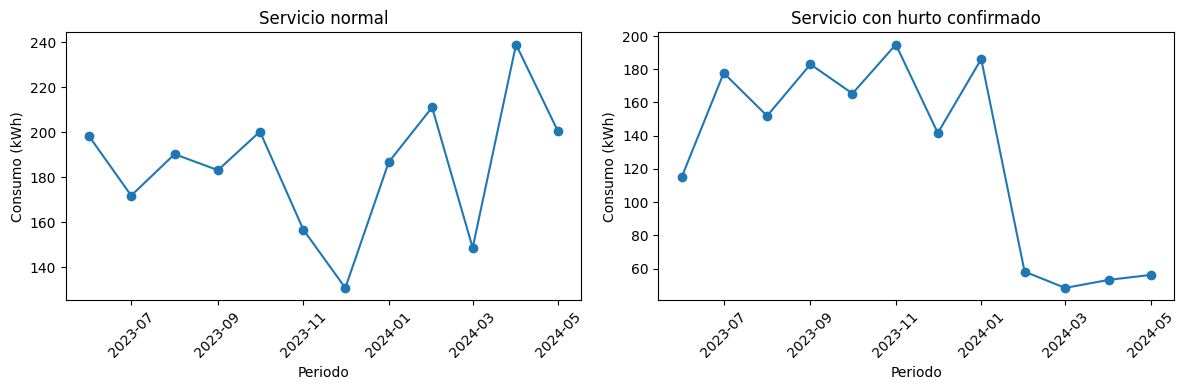

In [3]:
import matplotlib.pyplot as plt

ejemplo_normal = df[df['Hurtos'] == 0]['IdNroServicio'].iloc[0]
ejemplo_hurto = df[df['Hurtos'] == 1]['IdNroServicio'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, servicio, titulo in zip(
    axes, [ejemplo_normal, ejemplo_hurto], ["Servicio normal", "Servicio con hurto confirmado"]
):
    sub = df[df['IdNroServicio'] == servicio]
    ax.plot(sub['Periodo'], sub['ConsumoEAT'], marker='o')
    ax.set_title(titulo)
    ax.set_xlabel("Periodo")
    ax.set_ylabel("Consumo (kWh)")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [4]:
df.groupby('Tarifa')['ConsumoEAT'].describe()


,count,mean,std,min,25%,50%,75%,max
Tarifa,,,,,,,,
Comercial,1044.0,504.677711,117.072468,34.47,435.8175,509.84,580.9225,904.42
Industrial,336.0,2376.935417,537.784960,896.70,2075.4600,2436.04,2736.3750,3797.01
Residencial,2220.0,171.257865,41.538101,14.79,149.5400,175.71,199.6100,299.76


## 🧠 Modelado

Se calculan características agregadas por servicio a partir de su serie de tiempo de consumo: **media, mínimo, máximo, desviación estándar y tendencia** (pendiente de una regresión lineal simple sobre el consumo en el tiempo). La tendencia es la característica más importante: una caída sostenida se traduce en una pendiente fuertemente negativa, mientras que un servicio normal con estacionalidad leve tiene una pendiente cercana a cero.

Dos modelos en paralelo:
1. **K-Means (2 clusters)** sobre las características, sin usar la etiqueta `Hurtos`, para ver si el comportamiento de consumo por sí solo separa a los servicios en grupos coherentes.
2. **Random Forest + SMOTE**, supervisado, usando la etiqueta real. El desbalance de clases (13% hurto) se corrige con SMOTE sobre el conjunto de entrenamiento, nunca sobre el de prueba.


In [5]:
from scipy.stats import linregress

def calcular_caracteristicas(grupo):
    consumo = grupo['ConsumoEAT'].values
    x = np.arange(len(consumo))
    pendiente = linregress(x, consumo).slope
    return pd.Series({
        "ConsumoEAT_Mean": consumo.mean(),
        "ConsumoEAT_Min": consumo.min(),
        "ConsumoEAT_Max": consumo.max(),
        "ConsumoEAT_Std": consumo.std(),
        "Tendencia": pendiente,
        "Hurtos": grupo['Hurtos'].iloc[0],
        "Tarifa": grupo['Tarifa'].iloc[0],
    })

df_features = df.groupby('IdNroServicio').apply(calcular_caracteristicas).reset_index()
df_features.head()


,IdNroServicio,ConsumoEAT_Mean,ConsumoEAT_Min,ConsumoEAT_Max,ConsumoEAT_Std,Tendencia,Hurtos,Tarifa
0,100000,184.729167,130.74,239.04,28.172486,1.434231,0,Residencial
1,100001,490.616667,292.11,686.54,117.112567,11.656993,0,Comercial
2,100002,127.641667,48.36,194.91,56.014120,-10.872308,1,Residencial
3,100003,546.903333,334.20,773.46,119.965595,14.798182,0,Comercial
4,100004,1652.941667,896.70,2970.20,684.564023,-126.781259,1,Industrial


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cols_num = ["ConsumoEAT_Mean", "ConsumoEAT_Min", "ConsumoEAT_Max", "ConsumoEAT_Std", "Tendencia"]
X_scaled = StandardScaler().fit_transform(df_features[cols_num])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_features['Cluster'] = kmeans.fit_predict(X_scaled)

pd.crosstab(df_features['Cluster'], df_features['Hurtos'])


Hurtos,0,1
Cluster,,
0,235,37
1,25,3


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

X = df_features[cols_num]
y = df_features['Hurtos']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

clf = RandomForestClassifier(
    random_state=42, n_estimators=200, class_weight='balanced'
)
clf.fit(X_train_bal, y_train_bal)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 📊 Evaluación

- El reporte de clasificación se lee con cuidado: en un problema desbalanceado, el *accuracy* general es engañoso, así que el foco está en **recall de la clase hurto** (cuántos hurtos reales detecta) y en el AUC-ROC.
- También se revisa qué tan importante es cada característica para el modelo: si la tendencia domina, confirma que el patrón de caída sostenida es la señal principal, tal como se diseñó.


              precision    recall  f1-score   support

    No hurto       0.93      0.98      0.96        65
       Hurto       0.83      0.50      0.62        10

    accuracy                           0.92        75
   macro avg       0.88      0.74      0.79        75
weighted avg       0.91      0.92      0.91        75

AUC-ROC: 0.859


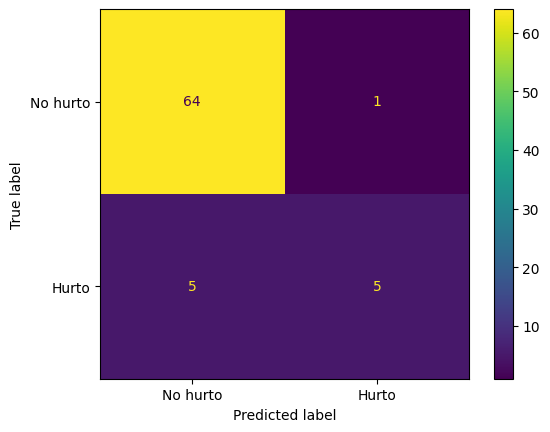

In [8]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No hurto", "Hurto"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No hurto", "Hurto"])
plt.show()


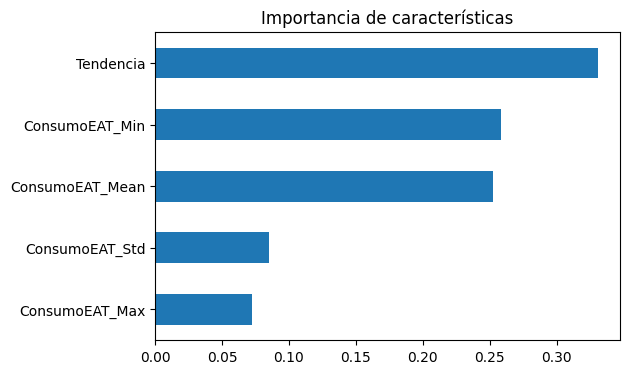

In [9]:
importancias = pd.Series(clf.feature_importances_, index=cols_num).sort_values(ascending=False)
importancias.plot(kind='barh', figsize=(6, 4), title="Importancia de características")
plt.gca().invert_yaxis()
plt.show()


## ✅ Hallazgos principales

- La **tendencia del consumo** (pendiente de la serie de tiempo) resultó ser, por diseño y por resultado del modelo, la característica más determinante para separar hurto de no-hurto — más que la media o el máximo de consumo por sí solos.
- El clustering no supervisado (K-Means) logra separar en buena medida el comportamiento, pero **no reemplaza** al clasificador supervisado: hay servicios de consumo naturalmente bajo que el clustering agrupa junto a los hurtos, y ahí es donde el modelo supervisado con la etiqueta real marca la diferencia.
- SMOTE ayudó a que el Random Forest no ignorara la clase minoritaria, pero el desbalance real de la distribución subyacente sigue siendo un reto: el recall de la clase hurto es el número que hay que vigilar en producción, no el accuracy general.
- Este pipeline no busca reemplazar la inspección de campo: busca **priorizar** a qué servicios mandar al inspector primero, en lugar de una búsqueda exhaustiva o aleatoria.
